# 02 · Системы, категории и соблюдение SLA

Разбираемся, где сосредоточена нагрузка и насколько служба выдерживает целевые сроки реакции и решения.

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent / 'src'))
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from analysis import load_data, NAVY, STEEL, SKY, ORANGE, RED, GREEN, WD_ORDER
pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.grid': True,
                     'grid.color': '#e8ecf0', 'axes.unicode_minus': False})
t, flights, sla, systems, agents = load_data()
print('Обращений:', len(t), '| период:', t.created_at.min().date(), '—', t.created_at.max().date())
t.head(3)

Обращений: 33309 | период: 2024-01-01 — 2025-12-31


,ticket_id,created_at,first_response_at,resolved_at,status,priority,category,system,criticality,is_critical_for_flights,zone,channel,reporter_role,team,agent_id,...,sla_breached,reopened,service_downtime_min,delayed_flights,csat,date,hour,weekday,weekday_name,month,year,ym,resolution_hours,is_closed,is_open
0,DME-000001,2024-01-01 00:10:07,2024-01-01 00:24:07,2024-01-01 00:51:07,Закрыт,P2,Периферия,Рабочие станции (АРМ),Низкая,False,Служебные зоны,Телефон,Администрация аэропорта,1-я линия поддержки,AG-105,...,False,False,0,0,5.0,2024-01-01,0,0,Пн,1,2024,2024-01,0.683333,True,False
1,DME-000002,2024-01-01 00:24:48,2024-01-01 00:32:48,2024-01-01 00:50:48,Закрыт,P3,Периферия,Принтеры посадочных талонов,Средняя,True,Зона регистрации,Телефон,Авиакомпания,1-я линия поддержки,AG-102,...,False,False,0,0,5.0,2024-01-01,0,0,Пн,1,2024,2024-01,0.433333,True,False
2,DME-000003,2024-01-01 02:07:42,2024-01-01 02:18:42,2024-01-01 05:25:42,Закрыт,P3,Оборудование,Рабочие станции (АРМ),Низкая,False,ЦОД и серверная,Телефон,Операционный центр,Полевая служба,AG-126,...,False,False,0,0,4.0,2024-01-01,2,0,Пн,1,2024,2024-01,3.300000,True,False


## Парето по системам

Принцип 80/20: небольшое число систем даёт основную часть обращений.

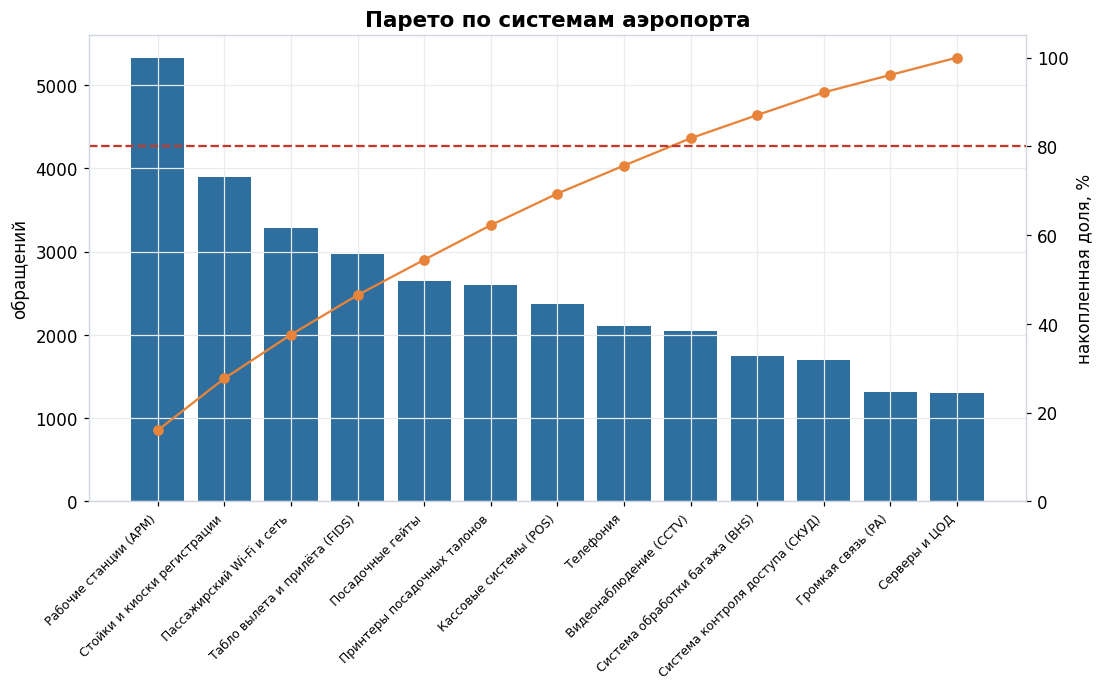

system
Рабочие станции (АРМ)            5331
Стойки и киоски регистрации      3892
Пассажирский Wi-Fi и сеть        3289
Табло вылета и прилёта (FIDS)    2967
Посадочные гейты                 2652
Принтеры посадочных талонов      2597
Кассовые системы (POS)           2374
Телефония                        2101


In [2]:
vc = t.system.value_counts(); cum = vc.cumsum() / vc.sum() * 100
fig, ax1 = plt.subplots(figsize=(11, 5.5))
ax1.bar(range(len(vc)), vc.values, color=STEEL)
ax1.set_xticks(range(len(vc))); ax1.set_xticklabels(vc.index, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('обращений')
ax2 = ax1.twinx(); ax2.plot(range(len(vc)), cum.values, color=ORANGE, marker='o'); ax2.grid(False)
ax2.axhline(80, color=RED, ls='--'); ax2.set_ylabel('накопленная доля, %'); ax2.set_ylim(0, 105)
ax1.set_title('Парето по системам аэропорта'); plt.show()
print(vc.head(8).to_string())

## Категории обращений и их критичность

Стек по приоритетам показывает не только объём категории, но и долю критичных заявок.

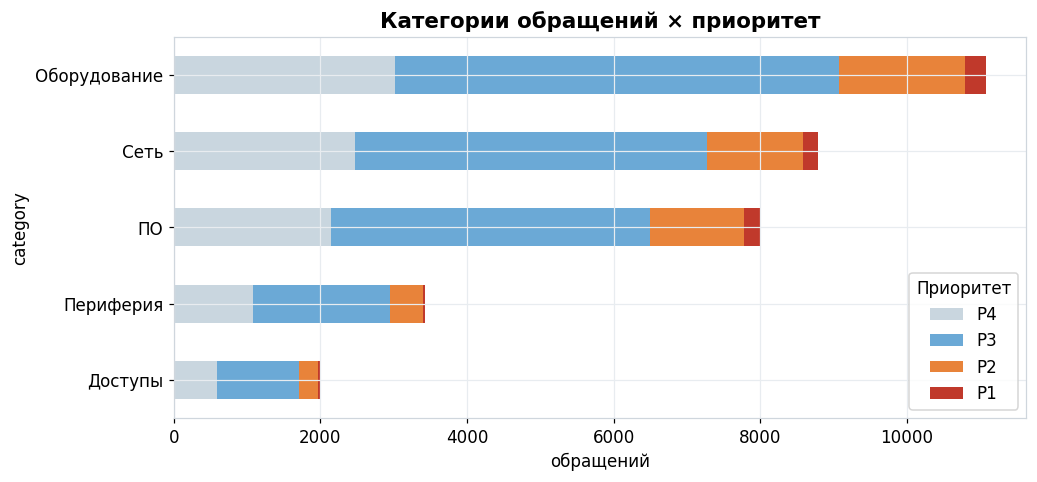

In [3]:
piv = t.pivot_table(index='category', columns='priority', values='ticket_id', aggfunc='count', fill_value=0)
piv = piv.loc[piv.sum(1).sort_values().index][['P4','P3','P2','P1']]
ax = piv.plot(kind='barh', stacked=True, figsize=(10, 4.5), color=['#c9d6df', SKY, ORANGE, RED])
ax.set_title('Категории обращений × приоритет'); ax.set_xlabel('обращений'); ax.legend(title='Приоритет')
plt.show()

## Соблюдение SLA по приоритетам

Сравниваем два SLA — на **первичную реакцию** и на **решение**. Пунктир — цель 90%.

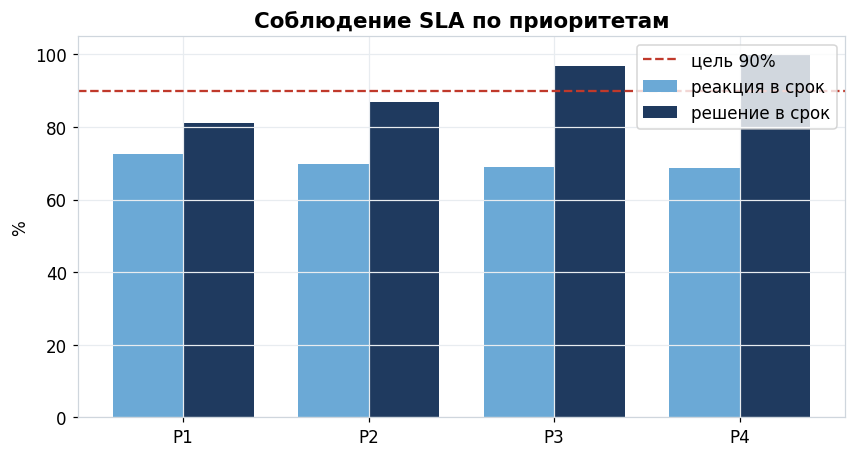

,реакция_в_срок_%,решение_в_срок_%
priority,,
P1,72.6,81.0
P2,69.7,86.9
P3,69.0,96.8
P4,68.8,99.8


In [4]:
c = t[t.is_closed]
order = ['P1','P2','P3','P4']
resp = (c.groupby('priority').sla_response_met.mean()*100).reindex(order)
res = (c.groupby('priority').sla_resolution_met.mean()*100).reindex(order)
x = np.arange(4); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x-w/2, resp.values, w, color=SKY, label='реакция в срок')
ax.bar(x+w/2, res.values, w, color=NAVY, label='решение в срок')
ax.axhline(90, color=RED, ls='--', label='цель 90%')
ax.set_xticks(x); ax.set_xticklabels(order); ax.set_ylim(0, 105); ax.set_ylabel('%'); ax.legend()
ax.set_title('Соблюдение SLA по приоритетам'); plt.show()
pd.DataFrame({'реакция_в_срок_%': resp.round(1), 'решение_в_срок_%': res.round(1)})

## Время решения и нарушения по системам

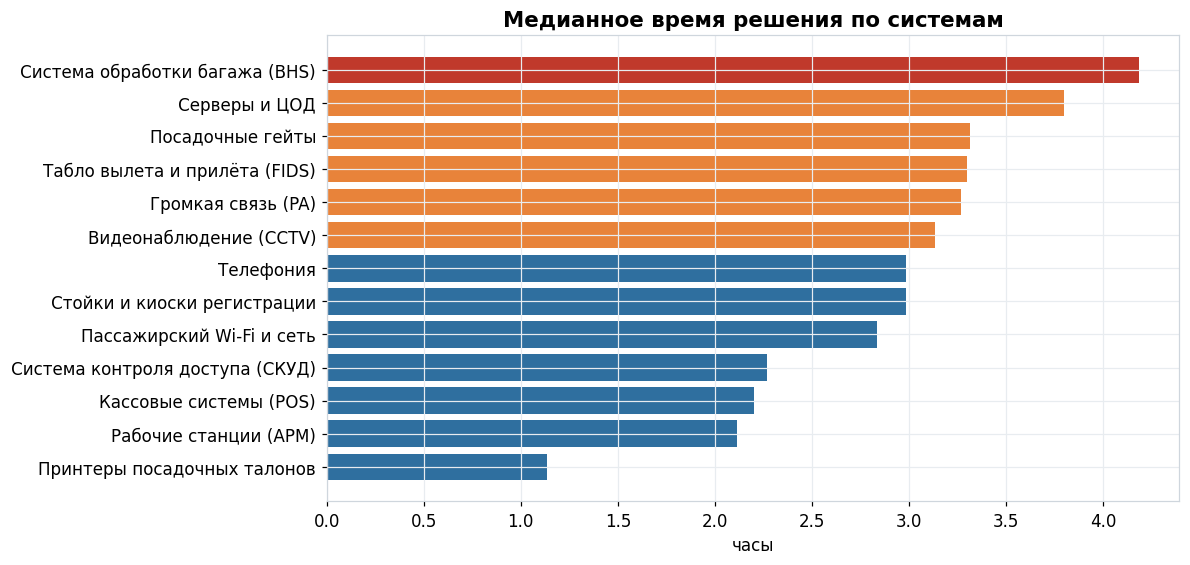

Доля нарушений SLA по решению, топ-6 систем:
system
Система обработки багажа (BHS)     16.6
Серверы и ЦОД                      14.6
Стойки и киоски регистрации         6.1
Табло вылета и прилёта (FIDS)       5.7
Посадочные гейты                    5.5
Система контроля доступа (СКУД)     3.8


In [5]:
med = c.groupby('system').resolution_hours.median().sort_values()
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(med.index, med.values, color=[RED if v>=4 else ORANGE if v>=3 else STEEL for v in med.values])
ax.set_title('Медианное время решения по системам'); ax.set_xlabel('часы'); plt.show()
print('Доля нарушений SLA по решению, топ-6 систем:')
print((c.groupby('system').sla_breached.mean()*100).sort_values(ascending=False).round(1).head(6).to_string())

## Нагрузка дня и срывы реакции

Проверяем гипотезу: чем выше дневная нагрузка, тем чаще срывается первичная реакция.

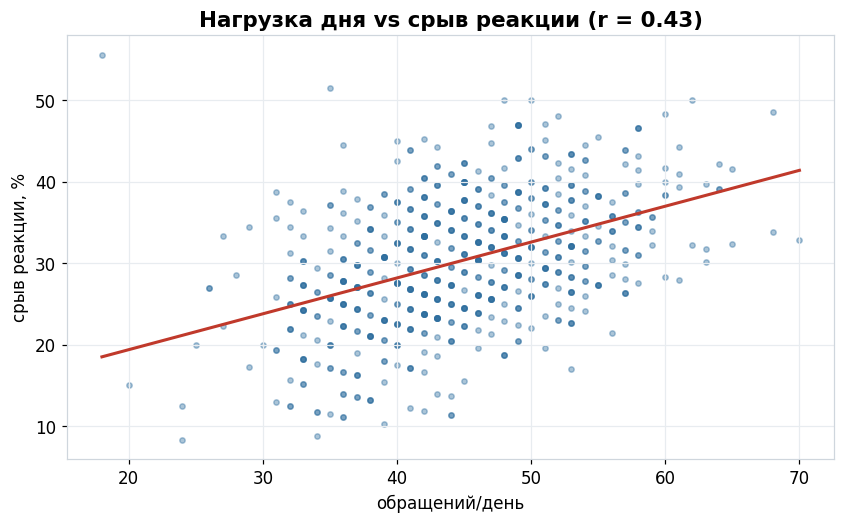

In [6]:
d = c.groupby('date').agg(volume=('ticket_id','count'), rb=('sla_response_met', lambda s: 1-s.mean()))
r = np.corrcoef(d.volume, d.rb)[0,1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(d.volume, d.rb*100, s=12, alpha=.4, color=STEEL)
z = np.polyfit(d.volume, d.rb*100, 1); xs = np.linspace(d.volume.min(), d.volume.max(), 50)
ax.plot(xs, np.polyval(z, xs), color=RED, lw=2)
ax.set_title(f'Нагрузка дня vs срыв реакции (r = {r:.2f})'); ax.set_xlabel('обращений/день'); ax.set_ylabel('срыв реакции, %')
plt.show()

### Выводы блока

- **9 из 13 систем** дают ~80% обращений; лидеры — рабочие станции, киоски регистрации, Wi-Fi, табло FIDS.
- SLA на **решение** держится хорошо (кроме P1), а вот **реакция** — узкое место.
- Дольше всего чинят **BHS** и **серверы** — там же выше доля нарушений.
- Срыв реакции растёт с дневной нагрузкой — это вопрос расстановки смен (ноутбук 03).